In [1]:
from datascience import *
import numpy as np

import matplotlib.pyplot as plt

%matplotlib inline

/Users/ayushthasale07/Sarg<3/Data8/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
x = make_array(43, 20, 51, 7, 28, 34)

In [3]:
np.sort(x)

array([ 7, 20, 28, 34, 43, 51])

In [4]:
percentile(55, x)

34

In [5]:
sf = Table.read_table("san_francisco_2019.csv")
sf.show(3)

Organization Group,Department,Job Family,Job,Salary,Overtime,Benefits,Total Compensation
Public Protection,Adult Probation,Information Systems,IS Trainer-Journey,91332,0,40059,131391
Public Protection,Adult Probation,Information Systems,IS Engineer-Assistant,123241,0,49279,172520
Public Protection,Adult Probation,Information Systems,IS Business Analyst-Senior,115715,0,46752,162468


In [6]:
sf.sort("Total Compensation", descending=True).show(5)

Organization Group,Department,Job Family,Job,Salary,Overtime,Benefits,Total Compensation
General Administration & Finance,Retirement Services,Administrative & Mgmt (Unrep),Chief Investment Officer,577633,0,146398,724031
General Administration & Finance,Retirement Services,Unassigned,Managing Director,483072,0,134879,617951
General Administration & Finance,Retirement Services,Unassigned,Managing Director,482649,0,134905,617554
General Administration & Finance,Retirement Services,Unassigned,Managing Director,451507,0,120276,571784
General Administration & Finance,Retirement Services,Unassigned,Managing Director,449378,0,120857,570235


In [10]:
min_salary = 15*20*50
sf = sf.where("Salary", are.above(min_salary))

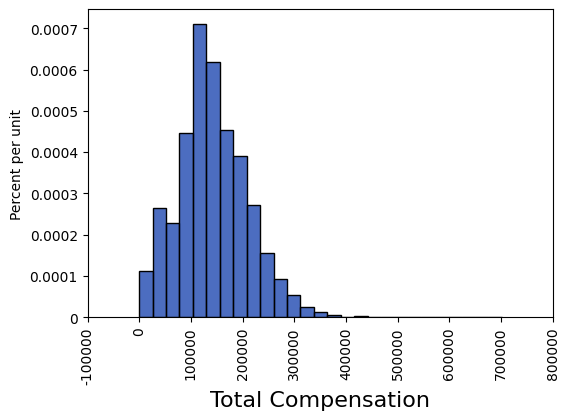

In [11]:
sf_bins = np.arange(0, 726000, 26000)
sf.hist("Total Compensation", bins=sf_bins)

In [12]:
pop_median = percentile(50, sf.column("Total Compensation"))
pop_median

135747.0

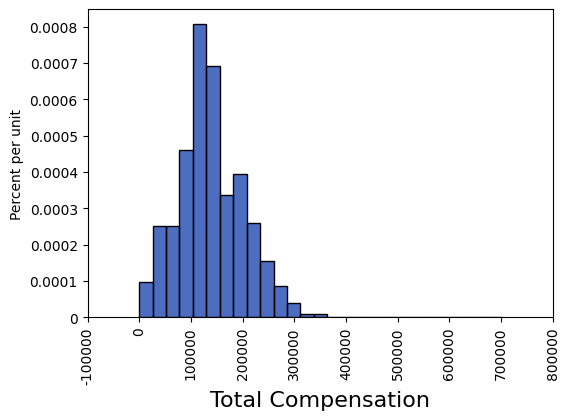

In [13]:
our_sample = sf.sample(400, with_replacement=False)
our_sample.hist("Total Compensation", bins=sf_bins)

In [14]:
percentile(50, our_sample.column("Total Compensation"))

131486.0

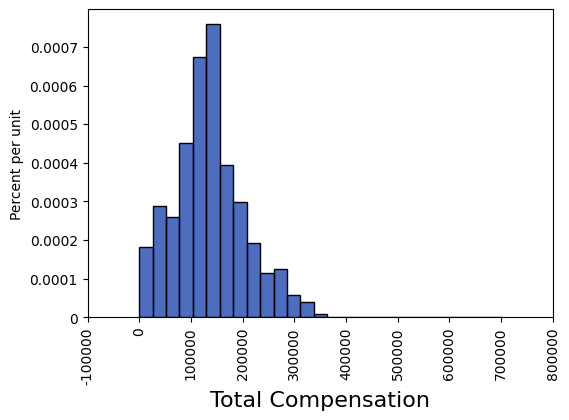

In [16]:
# Bootstrap : With Replacement from Sample
# bootstrap_sample = our_sample.sample(our_sample.num_rows, with_replacement=True) same as
bootstrap_sample = our_sample.sample()
bootstrap_sample.hist("Total Compensation", bins=sf_bins)

In [17]:
percentile(50, our_sample.column("Total Compensation"))

131486.0

In [18]:
def one_bootstrap_median():
    resample = our_sample.sample()
    return percentile(50, resample.column("Total Compensation"))

In [19]:
num_reps = 1000
bstrap_meds = make_array()

for i in range(num_reps):
    bstrap_meds = np.append(bstrap_meds, one_bootstrap_median())

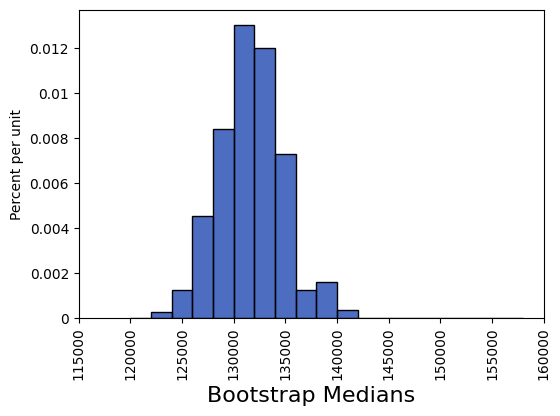

In [24]:
median_bins = np.arange(120000, 160000, 2000)
Table().with_column("Bootstrap Medians", bstrap_meds).hist("Bootstrap Medians", bins=median_bins)